# Shepp-Logan Phantom — Out-of-Distribution Poisson Inverse Problem

**Goal**: show that the flow-matching (stochastic-interpolants) posterior sampler works
**reasonably well** even when the true parameter lies far outside the smooth
BiLaplacian Gaussian prior used for training.

| Item | Description |
|------|-------------|
| PDE | −div(exp(m) ∇u) = 1 on [0,1]², Dirichlet BC u = x₁ on top/bottom |
| Observations | 100 pointwise state values on a 10×10 interior grid |
| True parameter | Shepp-Logan phantom: log(40) ≈ 3.69 inside, log(3) ≈ 1.10 outside |
| Training prior | BiLaplacianPrior(γ=1, δ=9) — smooth Gaussian random fields |
| Training data | 50 000 prior samples from `../poisson/sl-data/` |

The Shepp-Logan phantom has a **sharp discontinuity** at its boundary — strongly OOD
relative to the smooth Gaussian process training distribution.  
MCMC / MAP methods are expected to work (given a weak enough likelihood), and we
show that flow matching is competitive.

> **Prerequisite**: run `generate_shepp_logan_data.py` (with the `poisson-fenics` conda env)
> before running this notebook.  Outputs are stored in `shepp-logan-data/`.

In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '2'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'

from pathlib import Path
from typing import Callable, List

import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import jax
import jax.numpy as jnp
from jax import random
import optax
import equinox as eqx

from triangular_transport.flows.flow_trainer import NNTrainer
from triangular_transport.flows.interpolants import (
    linear_interpolant, linear_interpolant_der, sigmoid_interpolant, sigmoid_interpolant_der
)
from triangular_transport.flows.loss_functions import vec_field_loss
from triangular_transport.flows.methods.utils import UnitGaussianNormalizer
from triangular_transport.flows.dataloaders import gaussian_reference_sampler

TRAIN_DIR  = Path('../poisson/training_dataset')   # same training data as poisson/sl_test.ipynb
SL_DIR = Path('shepp-logan-data')          # generated by generate_shepp_logan_data.py

print('JAX devices:', jax.devices())

JAX devices: [CudaDevice(id=0)]


In [2]:
class MLP(eqx.Module):
    layers: List[eqx.nn.Linear]
    norms:  List[eqx.nn.LayerNorm]
    skips:  List[eqx.nn.Linear | None]
    out:    eqx.nn.Linear
    activation_fn: List[Callable]

    def __init__(
        self,
        key: jax.random.PRNGKey,
        dim: int,
        out_dim: int | None = None,
        num_layers: int = 4,
        activation_fn: List[Callable] | Callable = jax.nn.gelu,
        w: int | List[int] = 64,
        time_varying: bool = False,
    ):
        if out_dim is None:
            out_dim = dim
        if isinstance(activation_fn, list):
            if len(activation_fn) == 1:
                activation_fn *= num_layers - 1
        else:
            activation_fn = [activation_fn] * (num_layers - 1)
        self.activation_fn = activation_fn
        if isinstance(w, list):
            if len(w) == 1:
                w *= (num_layers - 1)
            widths = w
        else:
            widths = [w] * (num_layers - 1)
        k = jax.random.split(key, 2 * num_layers + 1)
        in_dim0 = dim + (1 if time_varying else 0)
        self.layers = []
        self.norms  = []
        self.skips  = []
        in_dim = in_dim0
        for i, width in enumerate(widths):
            self.layers.append(eqx.nn.Linear(in_dim, width, key=k[i]))
            self.norms.append(eqx.nn.LayerNorm(width))
            if in_dim == width:
                self.skips.append(None)
            else:
                self.skips.append(eqx.nn.Linear(in_dim, width, key=k[i + num_layers]))
            in_dim = width
        self.out = eqx.nn.Linear(in_dim, out_dim, key=k[-1])

    def __call__(self, x):
        for layer, norm, skip, act in zip(self.layers, self.norms,
                                           self.skips, self.activation_fn):
            h = layer(x)
            h = norm(h)
            h = act(h)
            s = x if skip is None else skip(x)
            x = h + s
        return self.out(x)

## 1. Load training data
Same 125k-sample dataset used in `poisson/sl_test.ipynb`.  
We use the first 50k for training, the next 50k as a reference distribution, and
20k test samples to initialise the inference ODE.

In [3]:
train_dim   = 50000
nx = ny     = 33
flat_length = nx * ny          # 1089

ys = np.load(TRAIN_DIR / 'solutions_grid_delta.npy')[:train_dim]                           # (50000, 100)
us = np.load(TRAIN_DIR / 'parameters_delta.npy')[:train_dim].reshape(train_dim, flat_length)  # (50000, 1089)

us_ref  = np.load(TRAIN_DIR / 'parameters_delta.npy')[train_dim:train_dim * 2].reshape(train_dim, flat_length)
np.random.shuffle(us_ref)

us_test = np.load(TRAIN_DIR / 'parameters_delta.npy')[train_dim * 2:train_dim * 2 + 20000].reshape(20000, flat_length)
np.random.shuffle(us_test)

print(f'ys  shape: {ys.shape}    (100-point noisy observations)')
print(f'us  shape: {us.shape}    (33x33 parameter fields)')
print(f'Prior parameter range: [{us.min():.2f}, {us.max():.2f}]')

ys  shape: (50000, 100)    (100-point noisy observations)
us  shape: (50000, 1089)    (33x33 parameter fields)
Prior parameter range: [-0.47, 0.50]


## 2. Normalisation and PCA
Observations are normalised to a unit Gaussian.  
Parameters are whitened via PCA, retaining 98% of the explained variance.

In [4]:
# Physical-residual normalisation:
#   1. Subtract B·u(m=0) from every observation (removes the BC-induced y-gradient that the
#      per-dimension normaliser would otherwise zero out independently, letting FM confuse
#      "high k throughout the phantom" with "high k at top").
#   2. Scale by a SINGLE global std (rather than per-dimension).  This preserves the natural
#      information weighting — boundary observation rows have lower variance and should
#      influence FM less — and reduces the Shepp-Logan-phantom z-score magnitudes from ±20–40 to ±6–9.
y_prior = np.load(SL_DIR / 'y_prior.npy')          # (100,)  B·u(m=0, k=1 everywhere)
ys_residual = ys - y_prior                              # (50000, 100)

obs_global_std = float(np.std(ys_residual))             # single scalar ~0.01
ys_normalized  = ys_residual / obs_global_std           # (50000, 100) globally scaled residuals

mean_us         = us.mean(axis=0)
_, S_full, Vt   = np.linalg.svd(us / np.sqrt(train_dim - 1), full_matrices=False)
V_full          = Vt.T
expl_var        = (S_full ** 2) / (S_full ** 2).sum()
k               = np.searchsorted(np.cumsum(expl_var), 0.999995) + 1
# k               = np.searchsorted(np.cumsum(expl_var), 0.999) + 1
V_pca           = V_full[:, :k]
S_pca           = S_full[:k]

def pca_encode(b):
    return (b - mean_us) @ V_pca / S_pca

def pca_decode(z):
    return mean_us + (z * S_pca) @ V_pca.T

print(f'PCA: k = {k} components (out of {flat_length} raw dims)')
print(f'y_prior range: [{y_prior.min():.4f}, {y_prior.max():.4f}]')
print(f'Residual global std: {obs_global_std:.5f}   (single scale applied to all 100 dims)')

PCA: k = 1079 components (out of 1089 raw dims)
y_prior range: [0.0737, 0.9737]
Residual global std: 0.01357   (single scale applied to all 100 dims)


In [5]:
us_pca      = pca_encode(us)
us_ref_pca  = pca_encode(us_ref)
us_test_pca = pca_encode(us_test)

target_data = jnp.hstack([ys_normalized, us_pca])      # (50000, 100 + k)
ref_data    = jnp.hstack([ys_normalized, us_ref_pca])  # reference distribution
print(f'Joint training tensor: {target_data.shape}  (100 obs + {int(k)} PCA dims)')

Joint training tensor: (50000, 1179)  (100 obs + 1079 PCA dims)


## 3. Flow-matching model
Same architecture and hyperparameters as `poisson/sl_test.ipynb`:
8-layer residual MLP (512-wide, SELU activations, LayerNorm), trained for 175k steps.

In [6]:
rng_key     = random.PRNGKey(42)
_, key_net  = random.split(rng_key)

obs_dim      = 100
yu_dimension = (obs_dim, int(k))
dim          = obs_dim + int(k)

model = MLP(
    key=key_net,
    dim=dim,
    time_varying=True,
    w=[1024] * 2,
    num_layers=3,
    activation_fn=jax.nn.relu,
)
schedule = optax.warmup_cosine_decay_schedule(
    init_value=0.0,
    peak_value=3e-4,
    warmup_steps=2_000,
    decay_steps=200_000,
    end_value=1e-6,
)
optimizer = optax.chain(optax.clip_by_global_norm(1.0), optax.adamw(schedule))

print(f'yu_dimension: {yu_dimension}   total input dim: {dim}')

yu_dimension: (100, 1079)   total input dim: 1179


In [7]:
trainer = NNTrainer(
    target_density=None,
    model=model,
    optimizer=optimizer,
    interpolant=linear_interpolant,
    interpolant_der=linear_interpolant_der,
    reference_sampler=gaussian_reference_sampler,
    loss=vec_field_loss,
    interpolant_args={'t': None, 'x1': None, 'x0': None},
    yu_dimension=yu_dimension,
)

trainer.train(
    train_data=target_data,
    train_dim=train_dim,
    batch_size=2048,
    steps=20000,
    x0_data=ref_data,
    print_every=10000,
);

Training neural network


  0%|          | 0/20000 [00:00<?, ?it/s]

step = 0, train_loss = 572.7160034179688


KeyboardInterrupt: 

## 4. Shepp-Logan phantom test point
Load the out-of-distribution observation generated by `generate_shepp_logan_data.py`.

True parameter: min=1.099  max=3.689
  log(3)=1.099  log(40)=3.689
Observations: raw [0.0564, 0.9472]  residual [-0.1573, 0.0118]
Normalised z-scores at boundary rows:
  y=0.05: mean z = -0.59
  y=0.95: mean z = -2.52


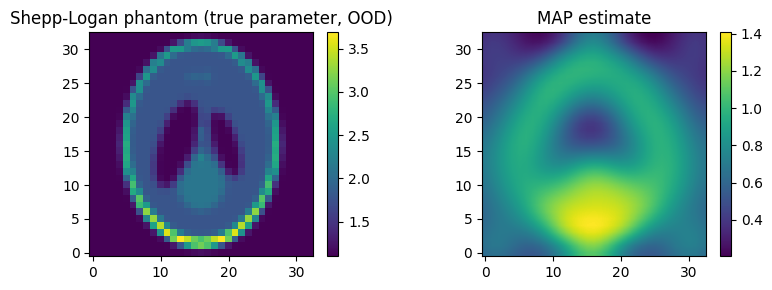

In [ ]:
yu_sl = np.load(SL_DIR / 'data_sl.npy')    # [y_obs (100,) | u_true (1089,)]
map_array = np.load(SL_DIR / 'map_array.npy')      # (33, 33) MAP estimate

y_obs      = yu_sl[:obs_dim]                        # (100,) noisy observations
u_true     = yu_sl[obs_dim:]                        # (1089,) true Shepp-Logan phantom
utrue_grid = u_true.reshape(nx, ny)

# Apply the same physical residual + global scale used during training
y_obs_residual = y_obs - y_prior                        # subtract B·u(m=0)
y_obs_norm     = y_obs_residual / obs_global_std        # same scale as training data

# Diagnostic: z-scores per row (should be ±6–9, not ±20–40)
targets = np.load(SL_DIR / 'targets.npy')
row_y   = np.unique(np.round(targets[:, 1], 3))
print(f'True parameter: min={u_true.min():.3f}  max={u_true.max():.3f}')
print(f'  log(3)={np.log(3):.3f}  log(40)={np.log(40):.3f}')
print(f'Observations: raw [{y_obs.min():.4f}, {y_obs.max():.4f}]  '
      f'residual [{y_obs_residual.min():.4f}, {y_obs_residual.max():.4f}]')
print(f'Normalised z-scores at boundary rows:')
for y_row in [row_y[0], row_y[-1]]:
    mask = np.abs(targets[:, 1] - y_row) < 1e-3
    z = float(np.mean(y_obs_norm[mask]))
    print(f'  y={y_row:.2f}: mean z = {z:+.2f}')

# Quick sanity plot
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
im0 = axes[0].imshow(utrue_grid, origin='lower', cmap='viridis')
axes[0].set_title('Shepp-Logan phantom (true parameter, OOD)')
axes[0].grid(False)
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
im1 = axes[1].imshow(map_array, origin='lower', interpolation='bilinear', cmap='viridis')
axes[1].set_title('MAP estimate')
axes[1].grid(False)
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## 5. Conditional sampling
Draw 20 000 posterior samples conditioned on the Shepp-Logan-phantom observation `y_obs`.

In [9]:
ys_normalized.shape

(50000, 100)

In [10]:
nsamples = 20000
cond_samples = trainer.conditional_sample(
    cond_values=jnp.array(y_obs_norm), u0_cond=us_test_pca, nsamples=nsamples
)
u_samps_pca = cond_samples[:, obs_dim:]
u_samps     = pca_decode(np.array(u_samps_pca)).reshape(nsamples, nx, ny)
u_fm_mean   = np.mean(u_samps, axis=0)
u_fm_var    = np.var(u_samps,  axis=0)

np.save(SL_DIR / 'fm_mean.npy', u_fm_mean)
np.save(SL_DIR / 'fm_var.npy', u_fm_var)

print(f'FM samples: {u_samps.shape}')
print(f'FM posterior mean range: [{u_fm_mean.min():.3f}, {u_fm_mean.max():.3f}]')

FM samples: (20000, 33, 33)
FM posterior mean range: [0.614, 2.355]


## 6. Results
### 6a. Four-panel diagnostic: true parameter · FM mean · MAP · FM variance

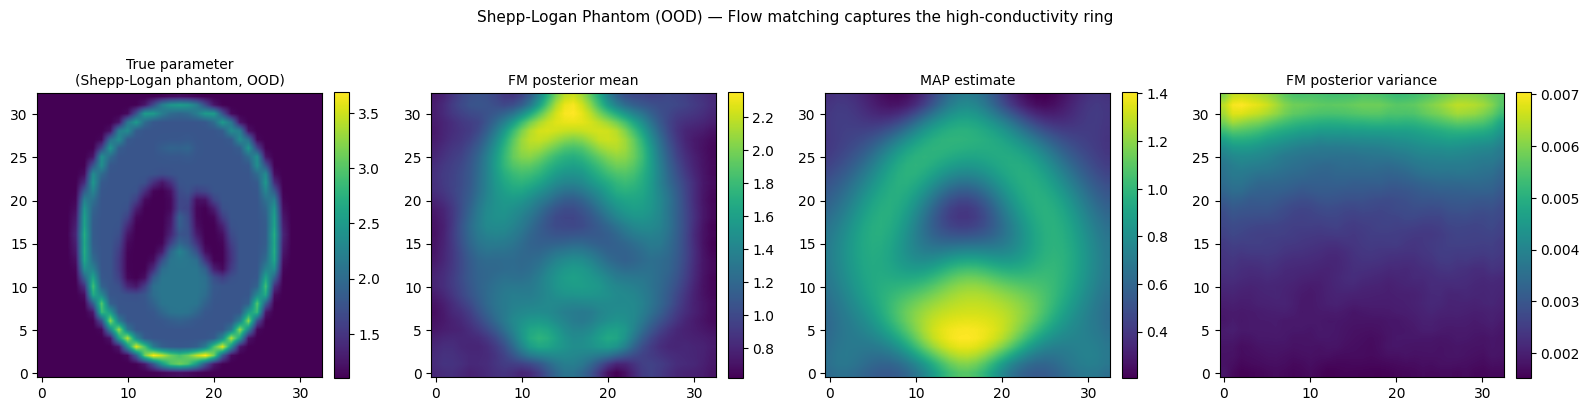

In [11]:
vmin = min(float(u_true.min()), float(u_fm_mean.min()), float(map_array.min()))
vmax = max(float(u_true.max()), float(u_fm_mean.max()), float(map_array.max()))

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
panels = [
    (utrue_grid, 'True parameter\n(Shepp-Logan phantom, OOD)', 'viridis', float(u_true.min()), float(u_true.max())),
    (u_fm_mean,  'FM posterior mean',                     'viridis', float(u_fm_mean.min()), float(u_fm_mean.max())),
    (map_array,  'MAP estimate',                          'viridis', float(map_array.min()), float(map_array.max())),
    (u_fm_var,   'FM posterior variance',                 'viridis',  None, None),
]
for ax, (arr, title, cmap, lo, hi) in zip(axes, panels):
    im = ax.imshow(arr, origin='lower', interpolation='bilinear',
                   cmap=cmap, vmin=lo, vmax=hi)
    ax.set_title(title, fontsize=10)
    ax.grid(False)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle(
    'Shepp-Logan Phantom (OOD) — Flow matching captures the high-conductivity ring',
    fontsize=11, y=1.02,
)
plt.tight_layout()
plt.savefig(SL_DIR / 'fm_results.png', dpi=120, bbox_inches='tight')
plt.show()

### 6b. Individual posterior samples

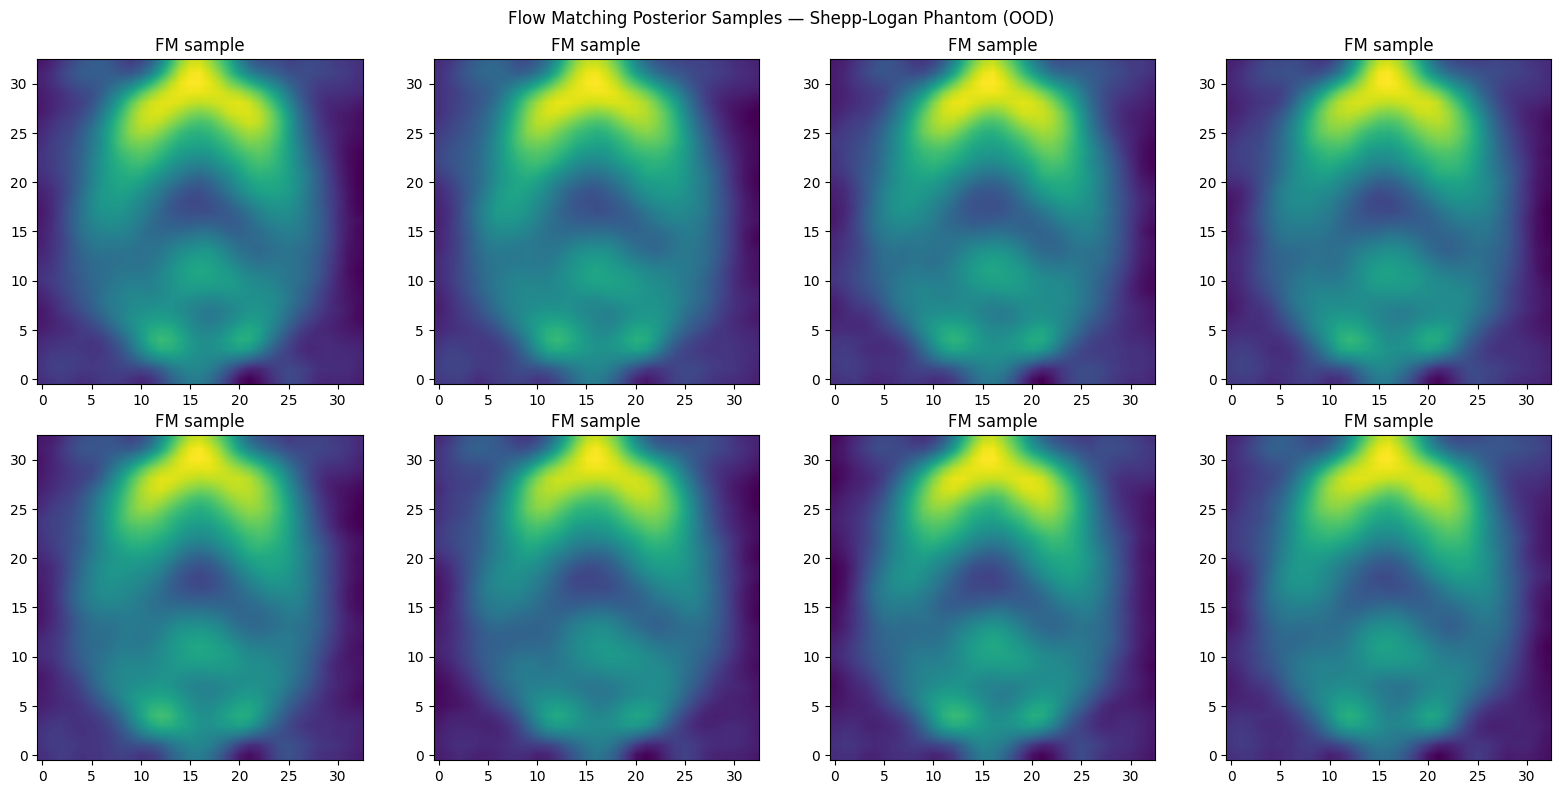

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
sample_idx = np.random.RandomState(0).choice(nsamples, 8, replace=False)
for ax, i in zip(axes.flat, sample_idx):
    ax.imshow(u_samps[i], origin='lower', interpolation='bilinear', cmap='viridis')
    ax.set_title('FM sample')
    ax.grid(False)
plt.suptitle('Flow Matching Posterior Samples — Shepp-Logan Phantom (OOD)', fontsize=12)
plt.tight_layout()
plt.show()

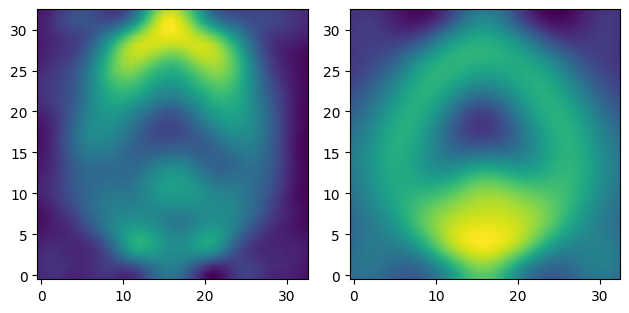

In [13]:
fig, ax = plt.subplots(1, 2)
ax[0].imshow(u_fm_mean, interpolation="bilinear", origin="lower")
ax[0].grid(False)
ax[1].imshow(map_array, interpolation="bilinear", origin="lower")
ax[1].grid(False)
plt.tight_layout()
plt.show()

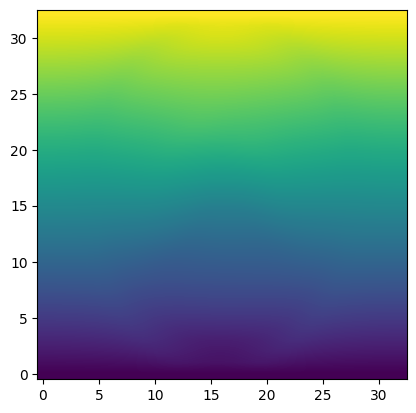

In [14]:
state_sl = np.load(SL_DIR / "state_sl.npy")
plt.imshow(state_sl.reshape(nx, ny), interpolation="bilinear", origin="lower")
plt.grid(False)

In [15]:
print(np.max(np.abs(y_obs_norm)))
print(np.mean(np.abs(y_obs_norm)))

# nearest training observations in normalized y-space
d = np.linalg.norm(ys_normalized - y_obs_norm[None, :], axis=1)
print(d.min(), np.percentile(d, [1, 5, 50]))

11.59017705004313
6.231589438130276
31.035110790630373 [48.68478938 54.65582049 69.2829722 ]


### 6c. Quantitative: Sliced Wasserstein Distance
Compare FM posterior samples to the prior distribution.  
A large SWD ratio confirms the model has updated from the OOD observation.

In [16]:
from ot.sliced import sliced_wasserstein_distance as swd

rng2   = np.random.RandomState(42)
n_swd  = 10000
i_ref  = rng2.choice(len(us_ref), n_swd, replace=False)

fm_flat    = u_samps[:n_swd].reshape(n_swd, nx * ny)
prior_flat = us_ref[i_ref]

swd_fm_prior   = swd(fm_flat, prior_flat,
                     n_projections=500, seed=42)
swd_prior_self = swd(prior_flat[:n_swd // 2], prior_flat[n_swd // 2:],
                     n_projections=500, seed=42)

print(f'SWD(FM posterior, prior):        {swd_fm_prior:.4f}')
print(f'SWD(prior, prior) noise floor:   {swd_prior_self:.4f}')
print(f'Ratio: {swd_fm_prior / max(swd_prior_self, 1e-8):.1f}x prior self-distance')
print()
print('A large ratio means the FM posterior is substantially different from the prior,')
print('confirming that the model extracted information from the OOD observation.')

SWD(FM posterior, prior):        1.3825
SWD(prior, prior) noise floor:   0.0032
Ratio: 435.2x prior self-distance

A large ratio means the FM posterior is substantially different from the prior,
confirming that the model extracted information from the OOD observation.
